# NB1 — Setup & Dataset Download + Data Exploration

**Steps:**
1. Install all dependencies
2. Mount Google Drive
3. Download and cache all 5 Kaggle datasets (NTHU-DDD, YawDD, CEW, MRL, Combined)
4. Explore class distributions and sample images

> **Before running:** Runtime → Change runtime type → **T4 GPU**
> Then: Runtime → Run all

---

In [1]:
# ── Install packages ───────────────────────────────────────────────────────────
# protobuf >=5.26.1,<6.0.0 satisfies both mediapipe AND TensorFlow/Google requirements
!pip install -q kagglehub mediapipe opencv-python-headless \
    pygame imbalanced-learn tqdm seaborn "protobuf>=5.26.1,<6.0.0"

import os, sys, cv2, random, time, shutil, urllib.request, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mediapipe as mp
import kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    accuracy_score, f1_score, precision_score, recall_score)

np.random.seed(42)
tf.random.set_seed(42)

# ── GPU check ──────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✓ GPU available: {gpus[0].name}')
else:
    print('✗ NO GPU — training will be slow.')
    print('  Fix: Runtime → Change runtime type → T4 GPU → Save')
    print('  Then: Runtime → Disconnect and delete runtime, reconnect, re-run all.')

import google.protobuf
print(f'TensorFlow : {tf.__version__}')
print(f'MediaPipe  : {mp.__version__}')
print(f'protobuf   : {google.protobuf.__version__}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 13.5 MB/s eta 0:00:00
✓ GPU available: /physical_device:GPU:0
TensorFlow : 2.19.0
MediaPipe  : 0.10.32
protobuf   : 5.29.6


In [2]:
# Mount Google Drive — models AND datasets are persisted here
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT  = '/content/drive/MyDrive/drowsiness'
MODEL_DIR   = f'{DRIVE_ROOT}/models'
DATASET_DIR = f'{DRIVE_ROOT}/datasets'

for d in [MODEL_DIR, DATASET_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Model dir  : {MODEL_DIR}")
print(f"Dataset dir: {DATASET_DIR}")


Mounted at /content/drive
Model dir  : /content/drive/MyDrive/drowsiness/models
Dataset dir: /content/drive/MyDrive/drowsiness/datasets


In [3]:

import os, shutil, tarfile, time
import kagglehub
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── paths ────────────────────────────────────────────────────────────────────
LOCAL_DS_ROOT = '/content/datasets'          # fast local NVMe SSD
os.makedirs(LOCAL_DS_ROOT, exist_ok=True)

DATASET_NAMES = {
    'nthu'    : 'nthu_ddd',
    'yawdd'   : 'yawdd',
    'cew'     : 'cew',
    'mrl'     : 'mrl_eye',
    'combined': 'combined',
}
KAGGLE_IDS = {
    'nthu'    : 'ismailnasri20/driver-drowsiness-dataset-ddd',
    'yawdd'   : 'enider/yawdd-dataset',
    'cew'     : 'prasadvpatil/eye-dataset',
    'mrl'     : 'akashshingha850/mrl-eye-dataset',
    'combined': 'prasadvpatil/mrl-dataset',
}

# ── core function: one dataset at a time (run concurrently) ──────────────────
def ensure_dataset(key):
    """
    Strategy (fast):
      1. If already extracted to local SSD → done immediately.
      2. If Drive has a .tar.gz archive → extract to local SSD (~1 FUSE read).
      3. Otherwise: kagglehub download → pack to .tar.gz on Drive (1 FUSE write)
                    → extract to local SSD.

    Why this is faster than the old approach:
      • Old: thousands of small FUSE writes (shutil.copytree to Drive),
             then thousands of small FUSE reads every training epoch.
      • New: ONE large tar.gz write on first run, ONE sequential read per
             session restart, everything else hits the local SSD.
    """
    local_path  = os.path.join(LOCAL_DS_ROOT, DATASET_NAMES[key])
    archive_path = os.path.join(DATASET_DIR, DATASET_NAMES[key] + '.tar.gz')
    t0 = time.perf_counter()

    # ── Step 1: already on local SSD (same Colab session) ────────────────────
    if os.path.isdir(local_path) and any(os.scandir(local_path)):
        print(f'[LOCAL ]  {key:10s}  (already extracted)')
        return key, local_path

    # ── Step 2: Drive has the archive → extract to local SSD ─────────────────
    if os.path.isfile(archive_path):
        print(f'[EXTRACT] {key:10s}  from Drive archive …')
        os.makedirs(local_path, exist_ok=True)
        with tarfile.open(archive_path, 'r:gz') as tf:
            tf.extractall(local_path)
        elapsed = time.perf_counter() - t0
        print(f'[DONE   ] {key:10s}  extracted in {elapsed:.1f}s  →  {local_path}')
        return key, local_path

    # ── Step 3: first run – download, archive to Drive, extract locally ───────
    print(f'[DOWNLOAD] {key:10s}  (kagglehub) …')
    raw_path = kagglehub.dataset_download(KAGGLE_IDS[key])
    print(f'[PACK    ] {key:10s}  → Drive archive {archive_path} …')
    # Pack to a single .tar.gz on Drive (ONE FUSE write, not thousands)
    with tarfile.open(archive_path, 'w:gz') as tf:
        tf.add(raw_path, arcname='.')
    print(f'[EXTRACT ] {key:10s}  → local SSD {local_path} …')
    os.makedirs(local_path, exist_ok=True)
    with tarfile.open(archive_path, 'r:gz') as tf:
        tf.extractall(local_path)
    elapsed = time.perf_counter() - t0
    print(f'[SAVED   ] {key:10s}  ready in {elapsed:.1f}s')
    return key, local_path

# ── download / extract all 5 datasets in PARALLEL ────────────────────────────
dataset_paths = {}
print('=== Parallel dataset preparation ===')
t_start = time.perf_counter()

with ThreadPoolExecutor(max_workers=5) as pool:
    futures = {pool.submit(ensure_dataset, key): key for key in DATASET_NAMES}
    for fut in as_completed(futures):
        key, path = fut.result()
        dataset_paths[key] = path

print(f'\nAll datasets ready in {time.perf_counter()-t_start:.1f}s total')

# ── convenience aliases (now pointing to fast local SSD, not Drive) ───────────
nthu_path     = dataset_paths['nthu']
yawdd_path    = dataset_paths['yawdd']
cew_path      = dataset_paths['cew']
mrl_path      = dataset_paths['mrl']
combined_path = dataset_paths['combined']

for k, v in dataset_paths.items():
    print(f'  {k:10s}: {v}')


=== Parallel dataset preparation ===
[EXTRACT] nthu        from Drive archive …
[EXTRACT] yawdd       from Drive archive …
[EXTRACT] cew         from Drive archive …
[EXTRACT] combined    from Drive archive …
[EXTRACT] mrl         from Drive archive …


/tmp/ipykernel_1086/656979818.py:53: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(local_path)


[DONE   ] cew         extracted in 5.8s  →  /content/datasets/cew
[DONE   ] combined    extracted in 8.6s  →  /content/datasets/combined
[DONE   ] mrl         extracted in 110.7s  →  /content/datasets/mrl_eye
[DONE   ] nthu        extracted in 141.3s  →  /content/datasets/nthu_ddd
[DONE   ] yawdd       extracted in 159.9s  →  /content/datasets/yawdd

All datasets ready in 160.0s total
  cew       : /content/datasets/cew
  combined  : /content/datasets/combined
  mrl       : /content/datasets/mrl_eye
  nthu      : /content/datasets/nthu_ddd
  yawdd     : /content/datasets/yawdd


---
## Section 2 â€” Data Exploration
Visualize sample images, folder structure, and class distributions.

Total images per dataset:
  NTHU-DDD    : 41,793
  YawDD       : 0
  CEW         : 4,848
  MRL IR      : 84,898
  Combined    : 4,000


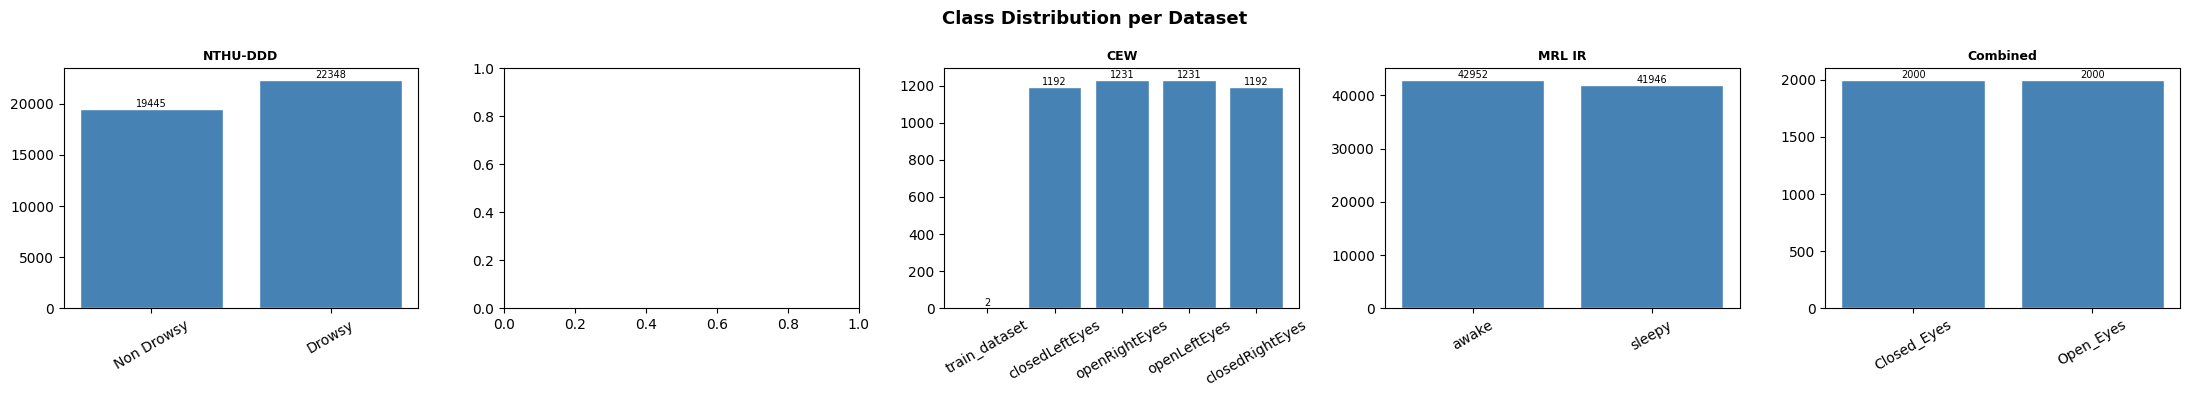

In [4]:
# Folder structure explorer
EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def count_classes(root):
    c = Counter()
    for p in Path(root).rglob("*"):
        if p.suffix.lower() in EXTS:
            c[p.parent.name] += 1
    return dict(c)

def get_imgs(root, n=3):
    imgs = []
    for p in Path(root).rglob("*"):
        if p.suffix.lower() in EXTS:
            imgs.append(str(p))
        if len(imgs) >= n: break
    return imgs

ds_list = [
    ("NTHU-DDD", nthu_path), ("YawDD", yawdd_path),
    ("CEW", cew_path), ("MRL IR", mrl_path), ("Combined", combined_path)
]

# Class distribution charts
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Class Distribution per Dataset", fontsize=13, fontweight="bold")
for ax, (name, path) in zip(axes, ds_list):
    counts = count_classes(path)
    if counts:
        bars = ax.bar(list(counts.keys()), list(counts.values()), color="steelblue", edgecolor="white")
        ax.bar_label(bars, fontsize=7)
        ax.set_title(name, fontsize=9, fontweight='bold')
        ax.tick_params(axis='x', rotation=30)
print("Total images per dataset:")
for name, path in ds_list:
    total = sum(count_classes(path).values())
    print(f"  {name:12s}: {total:,}")
plt.tight_layout(); plt.show()

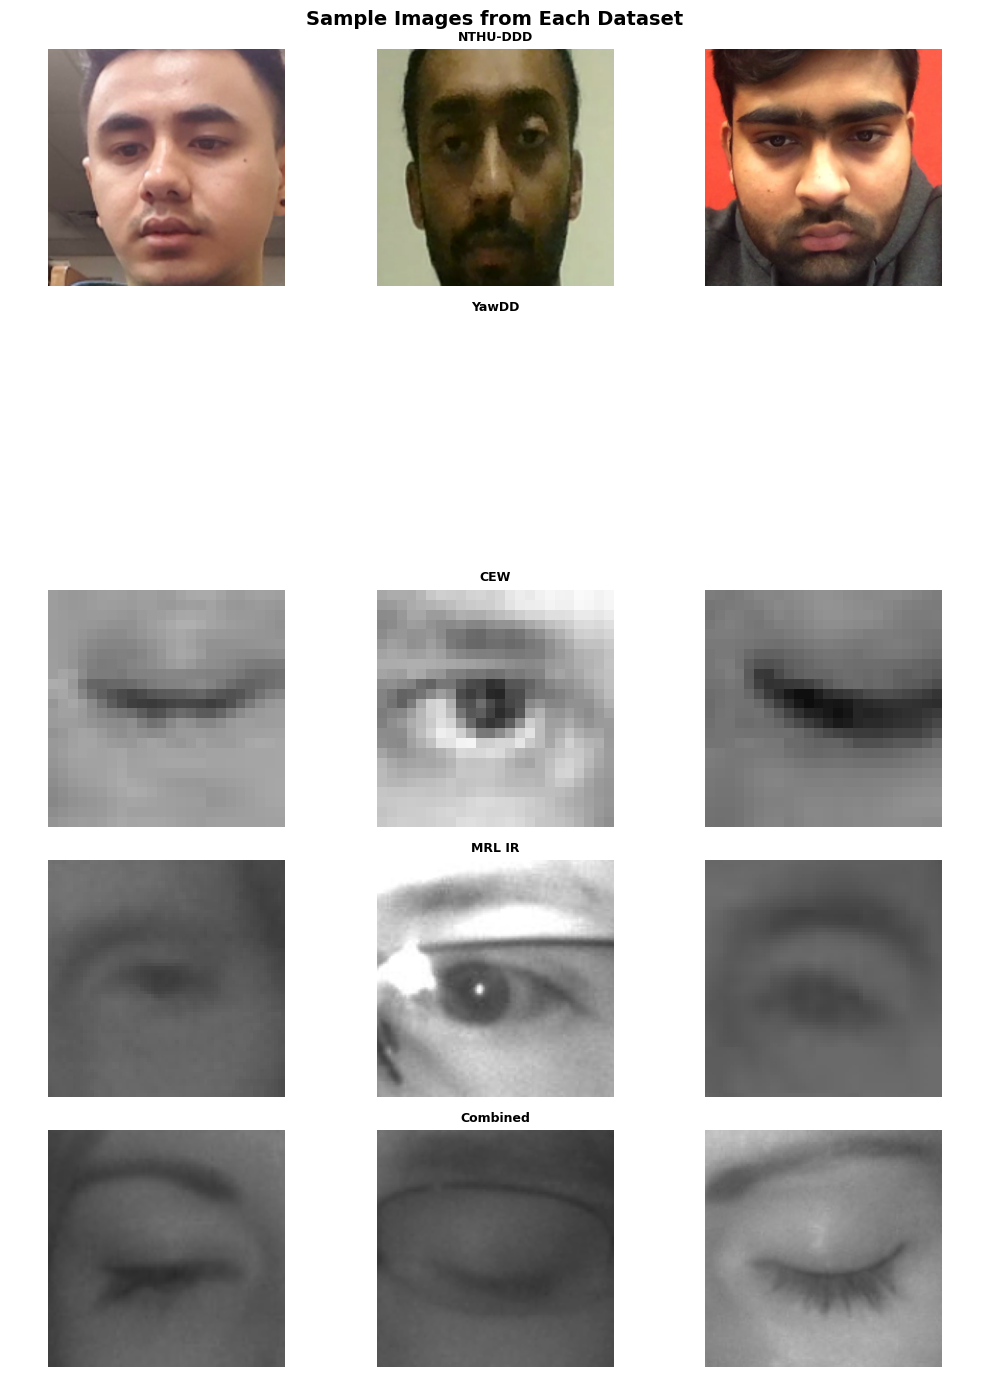

In [5]:
# Sample images (5 datasets x 3 images)
fig, axes = plt.subplots(5, 3, figsize=(10, 14))
fig.suptitle("Sample Images from Each Dataset", fontsize=14, fontweight="bold")
for row, (ds, path) in enumerate(ds_list):
    samples = get_imgs(path, 3)
    for col in range(3):
        ax = axes[row, col]; ax.axis('off')
        if col < len(samples):
            img = cv2.imread(samples[col])
            if img is not None:
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if col == 1: ax.set_title(ds, fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()